<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.48659

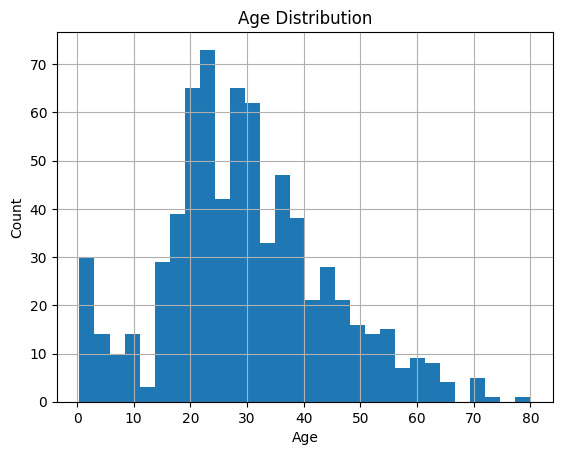

Standard deviation of Age: 14.53


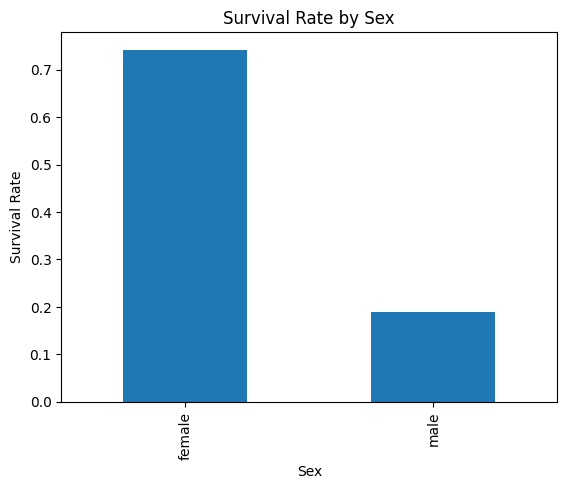

Cross-validation accuracy scores: [0.79329609 0.79775281 0.84269663 0.76966292 0.82022472]
Mean accuracy: 0.8047 (+/- 0.0249)


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

train = pd.read_csv("dataset/train.csv")

print(train.info())
print(train.describe())

# 1. Histogram of Age
train["Age"].hist(bins=30)
plt.xlabel("Age"); plt.ylabel("Count"); plt.title("Age Distribution")
plt.show()

# 2 Standard deviations for age outliers
print(f"Standard deviation of Age: {train['Age'].std():.2f}")

# 3 Survival rate based on sex
train.groupby("Sex")["Survived"].mean().plot.bar()
plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
plt.show()

# 4 Train a random forest model

# Combine siblings/spouses and parents/children into family size
train["FamilySize"] = train["SibSp"] + train["Parch"]
# Extract title from name like Mr..etc
train["Title"] = train["Name"].str.extract(r' ([A-Za-z]+)\.')


features = ["Pclass", "Sex", "Age", "Fare", "FamilySize", "Embarked", "Title"]
X = train[features]
y = train["Survived"]
# For numeric features, use median for imputation and standard scaling
num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())
# For text features, use most frequent for imputation and one-hot encoding
cat_pipeline = make_pipeline(SimpleImputer(strategy="most_frequent"), OneHotEncoder(handle_unknown="ignore"))

# Preprocess transformations
preprocessing = ColumnTransformer([
    ("num", num_pipeline, ["Pclass", "Age", "Fare", "FamilySize"]),
    ("cat", cat_pipeline, ["Sex", "Embarked", "Title"]),
])

# make random forest classifier pipeline
model = make_pipeline(preprocessing, RandomForestClassifier(n_estimators=100, random_state=42))

# Evaluate with cross-validation function
scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
print(f"Cross-validation accuracy scores: {scores}")
print(f"Mean accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")